In [ ]:
from matplotlib import pyplot as plt
from functions import *

# stop flow with reaction in 50 ul chip
# irradiation for tR, then uv-vis immediately after in the same chip
# flushed with fresh starting reaction mixture and repeated for new tR

# V(Ru(bpy)3, 12.5 mM, buffer) = 320 ul
# V(EV, 25 mM, buffer) = 960 ul
# V(EDTA, saturated, buffer) = 720 ul

data = f'./results/260707_Rubpy_EV_EDTA_StopFlow/'

XV = r"[EV$^{+\!\cdot\!}$]" # [XV+.]
XV0 = r"[EV$^{2\!+\!}$]$_0$" # [XV2+]0
tR = "$t_\\mathrm{R}$" # tR
c0 = solprop(cstock=25e-3, valiquot=720e-6, vsol=1.5e-3) # initial XV2+ concentration

tRs = [tR*30 for tR in range(1, 15)] # residence times in seconds for 1-7 minutes in 30s intervals

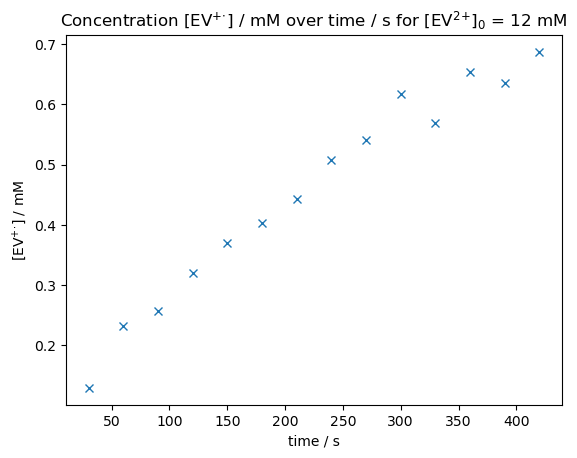

In [ ]:
# concentration vs time plot for each run
c = concvstimepoints(data, 600, 700e-6, 1.22e6)
plt.plot(tRs, [conc*1e3 for conc in c], "x") # plot time in seconds, concentrations in μM
plt.xlabel(r'time / s')
plt.ylabel(rf'{XV} / mM')
plt.title(rf'Concentration {XV} / mM over time / s for {XV0} = {c0*1e3:.0f} mM')
plt.show()

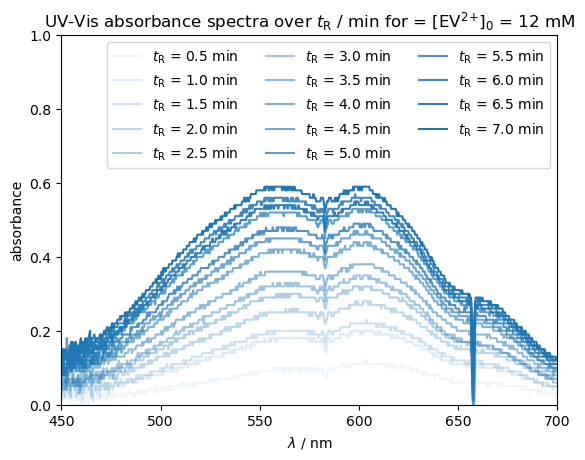

In [8]:
# absorbance spectra for each tR
l, a = spectrumvstimepoints(data)
for i in range(len(tRs)):
    plt.plot(l, a[i], color="#1F77B4", alpha=(i+1)/len(tRs), label=rf'{tR} = {tRs[i]/60} min')
plt.title(rf'UV-Vis absorbance spectra over {tR} / min for = {XV0} = {c0*1e3:.0f} mM')
plt.xlim(450, 700)
plt.ylim(0, 1)
plt.xlabel(r'$\lambda$ / nm')
plt.ylabel(r'absorbance')
plt.legend(ncols=3)
plt.show()